<a href="https://colab.research.google.com/github/emadyowakim/AI-ML/blob/master/Copy_of_Churn_Prediction_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — End-to-End ML Pipeline

A full applied ML workflow: data cleaning → EDA → feature engineering → model training/selection → evaluation → a lightweight inference function.

**Business problem:** An e-commerce/DTH provider wants to predict which customer accounts are at risk of churning so it can target retention offers before losing the account.

> **Data note:** This notebook expects `Customer Churn Data.xlsx` (a licensed Great Learning case-study dataset). Upload it when prompted in the cell below — it is **not** bundled with this notebook and should not be redistributed publicly.


## 1. Setup

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay,
)
from xgboost import XGBClassifier
import joblib
import json

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Data

Run the cell below and upload `Customer Churn Data.xlsx` when prompted (works in Google Colab via `google.colab.files`). If running outside Colab, just set `DATA_PATH` to a local file path instead.

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()  # select "Customer Churn Data.xlsx"
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    # Not running in Colab — set the path manually
    DATA_PATH = "Customer Churn Data.xlsx"

df_raw = pd.read_excel(DATA_PATH, sheet_name="Data for DSBA")
print("Shape:", df_raw.shape)
df_raw.head()

Saving Customer Churn Data.xlsx to Customer Churn Data.xlsx
Shape: (11260, 19)


,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

In [ ]:
print("Missing values per column:")
df_raw.isnull().sum().sort_values(ascending=False)

Missing values per column:


,0
cashback,471
Complain_ly,357
Day_Since_CC_connect,357
Login_device,221
Marital_Status,212
CC_Agent_Score,116
Account_user_count,112
City_Tier,112
Payment,109
Gender,108


In [ ]:
print("Churn rate (raw):")
df_raw["Churn"].value_counts(normalize=True)

Churn rate (raw):


,proportion
Churn,
0,0.831616
1,0.168384


## 3. Data Quality Investigation

Before cleaning, let's check the categorical columns for inconsistent labels or garbage placeholder values — a common real-world data issue.

In [ ]:
cat_cols = ["Payment", "Gender", "account_segment", "Marital_Status", "Login_device"]
for c in cat_cols:
    print(c, "->", df_raw[c].unique())

Payment -> ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan]
Gender -> ['Female' 'Male' 'F' nan 'M']
account_segment -> ['Super' 'Regular Plus' 'Regular' 'HNI' 'Regular +' nan 'Super Plus'
 'Super +']
Marital_Status -> ['Single' 'Divorced' 'Married' nan]
Login_device -> ['Mobile' 'Computer' '&&&&' nan]


In [ ]:
# Numeric-looking columns stored as strings often hide junk tokens
print("Tenure unique sample:", df_raw["Tenure"].unique()[:15])
print("rev_per_month unique sample:", df_raw["rev_per_month"].unique()[:15])

Tenure unique sample: [4 0 2 13 11 '#' 9 99 19 20 14 8 26 18 5]
rev_per_month unique sample: [9 7 6 8 3 2 4 10 1 5 '+' 130 nan 19 139]


**Findings:**
- `Gender` mixes `'F'`/`'Male'` style aliases with `'Female'`/`'Male'`.
- `account_segment` has inconsistent variants: `'Regular +'` vs `'Regular Plus'`, `'Super +'` vs `'Super Plus'`.
- `Login_device` contains a garbage token `'&&&&'`.
- `Tenure` (and likely other "numeric" columns) contains a `'#'` placeholder, which silently breaks numeric dtype inference and hides missingness.

## 4. Data Cleaning

In [ ]:
NUMERIC_COLS = [
    "Tenure", "City_Tier", "CC_Contacted_LY", "Service_Score",
    "Account_user_count", "CC_Agent_Score", "rev_per_month", "Complain_ly",
    "rev_growth_yoy", "coupon_used_for_payment", "Day_Since_CC_connect", "cashback",
]
CATEGORICAL_COLS = ["Payment", "Gender", "account_segment", "Marital_Status", "Login_device"]

GENDER_MAP = {"F": "Female", "M": "Male", "Female": "Female", "Male": "Male"}
SEGMENT_MAP = {
    "Regular +": "Regular Plus", "Regular Plus": "Regular Plus", "Regular": "Regular",
    "Super +": "Super Plus", "Super Plus": "Super Plus", "Super": "Super", "HNI": "HNI",
}
GARBAGE_TOKENS = ["&&&&", "#", "*", "?", ""]


def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Replace garbage tokens with NaN across all columns
    df = df.replace(GARBAGE_TOKENS, np.nan)

    # Coerce numeric columns (junk tokens become NaN automatically)
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Normalise categorical labels
    df["Gender"] = df["Gender"].map(GENDER_MAP).fillna(df["Gender"])
    df["account_segment"] = df["account_segment"].map(SEGMENT_MAP).fillna(df["account_segment"])
    for col in CATEGORICAL_COLS:
        # Plain object dtype (not pandas 'string' dtype) so sklearn imputers/encoders work correctly
        df[col] = df[col].astype(object).where(df[col].notna(), np.nan)
        df[col] = df[col].apply(lambda v: v.strip() if isinstance(v, str) else v)

    df = df.drop_duplicates(subset="AccountID")
    return df


df = clean(df_raw)
print("Cleaned shape:", df.shape)
df.isnull().sum().sort_values(ascending=False)

Cleaned shape: (11260, 19)


/tmp/ipykernel_7247/965459564.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(GARBAGE_TOKENS, np.nan)


,0
rev_per_month,791
Login_device,760
cashback,473
Account_user_count,444
Day_Since_CC_connect,358
Complain_ly,357
Tenure,218
Marital_Status,212
CC_Agent_Score,116
City_Tier,112


In [ ]:
# Confirm fixes
print(df["Gender"].unique())
print(df["account_segment"].unique())
print(df["Login_device"].unique())

['Female' 'Male' nan]
['Super' 'Regular Plus' 'Regular' 'HNI' nan 'Super Plus']
['Mobile' 'Computer' nan]


## 5. Exploratory Data Analysis

Overall churn rate: 16.8%


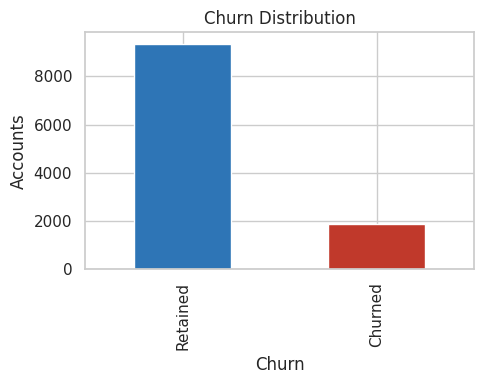

In [ ]:
churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

plt.figure(figsize=(5, 4))
df["Churn"].value_counts().rename({0: "Retained", 1: "Churned"}).plot(
    kind="bar", color=["#2E75B6", "#C0392B"]
)
plt.title("Churn Distribution")
plt.ylabel("Accounts")
plt.tight_layout()
plt.show()

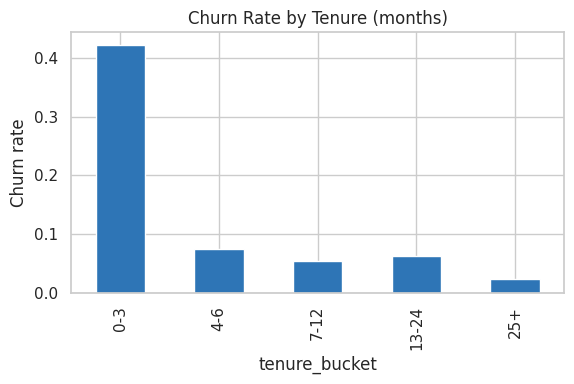

tenure_bucket
0-3      0.422594
4-6      0.075278
7-12     0.053869
13-24    0.062048
25+      0.024242
Name: Churn, dtype: float64


In [ ]:
df["tenure_bucket"] = pd.cut(
    df["Tenure"], bins=[-1, 3, 6, 12, 24, 100], labels=["0-3", "4-6", "7-12", "13-24", "25+"]
)
tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].mean()

plt.figure(figsize=(6, 4))
tenure_churn.plot(kind="bar", color="#2E75B6")
plt.title("Churn Rate by Tenure (months)")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(tenure_churn)

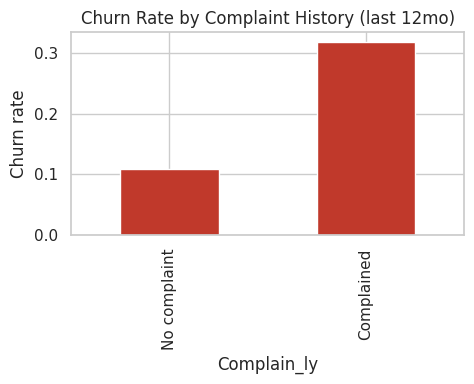

Complain_ly
0.0    0.109086
1.0    0.317583
Name: Churn, dtype: float64


In [ ]:
complaint_churn = df.groupby("Complain_ly")["Churn"].mean()

plt.figure(figsize=(5, 4))
complaint_churn.rename({0: "No complaint", 1: "Complained"}).plot(kind="bar", color="#C0392B")
plt.title("Churn Rate by Complaint History (last 12mo)")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(complaint_churn)

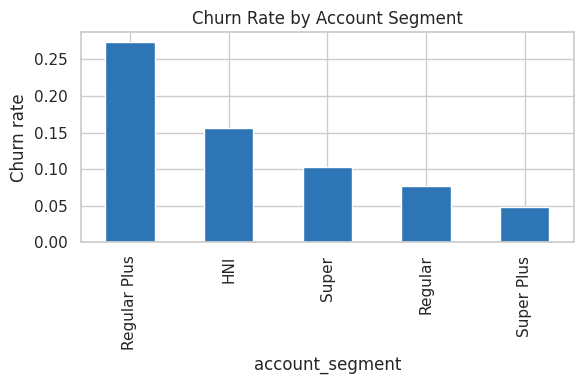

account_segment
Regular Plus    0.273278
HNI             0.155583
Super           0.102413
Regular         0.076923
Super Plus      0.048900
Name: Churn, dtype: float64


In [ ]:
seg_churn = df.groupby("account_segment")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
seg_churn.plot(kind="bar", color="#2E75B6")
plt.title("Churn Rate by Account Segment")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(seg_churn)

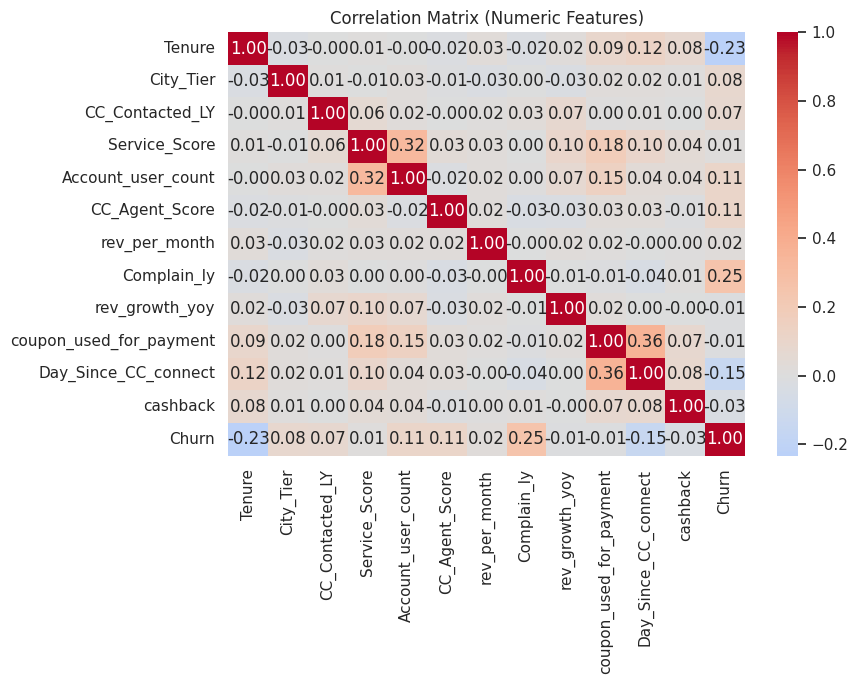

In [ ]:
numeric_cols = [
    "Tenure", "City_Tier", "CC_Contacted_LY", "Service_Score", "Account_user_count",
    "CC_Agent_Score", "rev_per_month", "Complain_ly", "rev_growth_yoy",
    "coupon_used_for_payment", "Day_Since_CC_connect", "cashback", "Churn",
]
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

**Key findings:**
- Churn rate is ~16.8% — imbalanced target, handled via class weighting rather than naive resampling.
- Tenure is strongly predictive: new accounts (0–3 months) churn far more than long-tenured ones.
- A recent complaint roughly triples churn risk.
- Churn risk varies considerably by account segment, suggesting segment-specific retention offers.

## 6. Feature Engineering & Preprocessing Pipeline

In [ ]:
TARGET = "Churn"
DROP_COLS = ["AccountID", "tenure_bucket"]  # drop helper column created during EDA

FEATURE_NUMERIC = NUMERIC_COLS
FEATURE_CATEGORICAL = CATEGORICAL_COLS

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (9008, 17)  Test shape: (2252, 17)


In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, FEATURE_NUMERIC),
    ("cat", categorical_pipeline, FEATURE_CATEGORICAL),
])

## 7. Model Training & Selection

Compare a Logistic Regression baseline against Random Forest and XGBoost, using 5-fold cross-validated ROC-AUC, then evaluate the held-out test set.

In [ ]:
candidates = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=5,  # approx. class imbalance ratio
    ),
}

results = {}
fitted_pipelines = {}

for name, model in candidates.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "cv_roc_auc": round(cv_auc, 4),
        "test_accuracy": round(accuracy_score(y_test, y_pred), 4),
        "test_precision": round(precision_score(y_test, y_pred), 4),
        "test_recall": round(recall_score(y_test, y_pred), 4),
        "test_f1": round(f1_score(y_test, y_pred), 4),
        "test_roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    }
    results[name] = metrics
    fitted_pipelines[name] = pipe

    print(f"=== {name} ===")
    print(json.dumps(metrics, indent=2))
    print(classification_report(y_test, y_pred))
    print()

=== logistic_regression ===
{
  "cv_roc_auc": 0.8491,
  "test_accuracy": 0.7571,
  "test_precision": 0.3929,
  "test_recall": 0.8127,
  "test_f1": 0.5297,
  "test_roc_auc": 0.8521
}
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1873
           1       0.39      0.81      0.53       379

    accuracy                           0.76      2252
   macro avg       0.67      0.78      0.68      2252
weighted avg       0.86      0.76      0.78      2252


=== random_forest ===
{
  "cv_roc_auc": 0.9772,
  "test_accuracy": 0.9485,
  "test_precision": 0.8247,
  "test_recall": 0.8813,
  "test_f1": 0.852,
  "test_roc_auc": 0.9808
}
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1873
           1       0.82      0.88      0.85       379

    accuracy                           0.95      2252
   macro avg       0.90      0.92      0.91      2252
weighted avg       0.95      0.95      0.95

In [ ]:
results_df = pd.DataFrame(results).T.sort_values("test_roc_auc", ascending=False)
results_df

,cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
xgboost,0.9766,0.9418,0.7719,0.9288,0.8431,0.9827
random_forest,0.9772,0.9485,0.8247,0.8813,0.8520,0.9808
logistic_regression,0.8491,0.7571,0.3929,0.8127,0.5297,0.8521


In [ ]:
best_name = results_df.index[0]
best_pipeline = fitted_pipelines[best_name]
print(f"Best model: {best_name} (test ROC-AUC = {results[best_name]['test_roc_auc']})")

Best model: xgboost (test ROC-AUC = 0.9827)


## 8. Evaluation of the Best Model

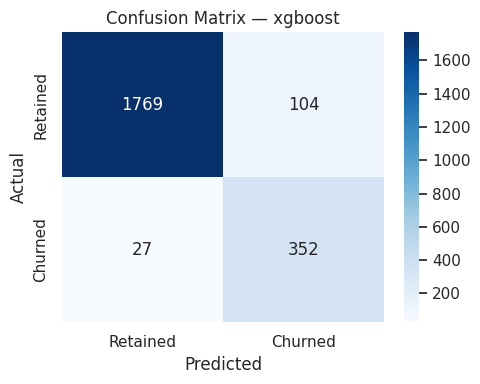

In [ ]:
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

<Figure size 500x500 with 0 Axes>

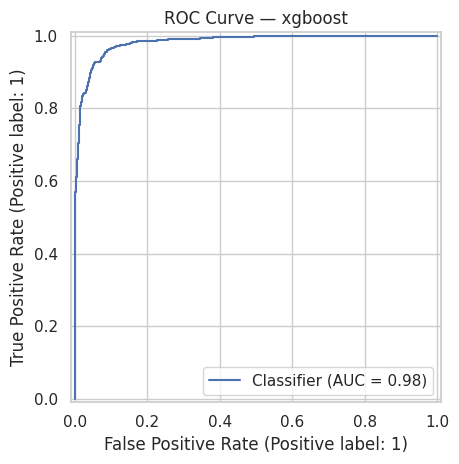

In [ ]:
plt.figure(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"ROC Curve — {best_name}")
plt.tight_layout()
plt.show()

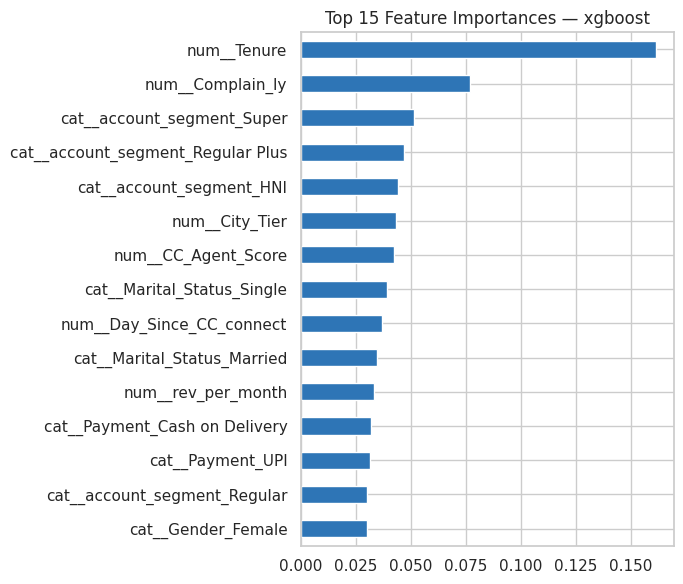

In [ ]:
# Feature importance (tree-based models)
if hasattr(best_pipeline.named_steps["model"], "feature_importances_"):
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = best_pipeline.named_steps["model"].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    plt.figure(figsize=(7, 6))
    fi.plot(kind="barh", color="#2E75B6")
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importances — {best_name}")
    plt.tight_layout()
    plt.show()

## 9. Save the Trained Pipeline

In [ ]:
joblib.dump(best_pipeline, "churn_model.joblib")
with open("metrics.json", "w") as f:
    json.dump({"results": results, "best_model": best_name}, f, indent=2)

print("Saved churn_model.joblib and metrics.json")

# In Colab, optionally download the artifacts:
try:
    from google.colab import files
    files.download("churn_model.joblib")
    files.download("metrics.json")
except ImportError:
    pass

Saved churn_model.joblib and metrics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Inference Demo

Simulates how the saved pipeline would be used in a serving context (e.g. the FastAPI service in the companion project).

In [ ]:
sample_account = pd.DataFrame([{
    "Tenure": 2, "City_Tier": 1, "CC_Contacted_LY": 12, "Payment": "UPI",
    "Gender": "Male", "Service_Score": 2, "Account_user_count": 4,
    "account_segment": "Regular Plus", "CC_Agent_Score": 2, "Marital_Status": "Single",
    "rev_per_month": 4, "Complain_ly": 1, "rev_growth_yoy": 8,
    "coupon_used_for_payment": 0, "Day_Since_CC_connect": 1,
    "cashback": 95.5, "Login_device": "Mobile",
}])

proba = best_pipeline.predict_proba(sample_account)[:, 1][0]
prediction = int(proba >= 0.5)
risk_band = "High" if proba >= 0.7 else "Medium" if proba >= 0.3 else "Low"

print(f"Churn probability: {proba:.2%}")
print(f"Prediction: {'Churn' if prediction else 'Retain'}")
print(f"Risk band: {risk_band}")

Churn probability: 87.65%
Prediction: Churn
Risk band: High


## 11. Business Recommendation

Given that **low-tenure (0–3 month) accounts** and **recent complainants** are the two highest-risk
segments identified in EDA, a targeted, low-cost retention nudge (e.g. a small loyalty cashback or
priority support queue) aimed specifically at new accounts that have just filed a complaint would
target the highest-risk intersection without broad, margin-eroding discounting.

---
*Built by Dr. Emad Yowakim as part of hands-on ML engineering preparation — demonstrating the full
data science lifecycle from raw, messy data through to a deployable, evaluated model.*